In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("employee_turnover.csv")

In [4]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

#### there are zero null values present in our dataset and no need for encoding is required as all the features are numerical

## Checking the balanced of classes which we have to predict

In [6]:
df.value_counts("Employee_Turnover")

Employee_Turnover
0    678
1    672
Name: count, dtype: int64

In [ ]:
# the data is almost balanced

In [8]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [11]:
df.nunique()

Job_Satisfaction                           900
Performance_Rating                         900
Years_At_Company                           900
Work_Life_Balance                          900
Distance_From_Home                         900
Monthly_Income                             900
Education_Level                            900
Age                                        900
Num_Companies_Worked                       900
Employee_Role                              900
Annual_Bonus                               900
Training_Hours                             900
Department                                 900
Annual_Bonus_Squared                       900
Annual_Bonus_Training_Hours_Interaction    900
Employee_Turnover                            2
dtype: int64

### from the dataset it is clearly visible that is encoded as well as it is scaled also and therefor we just have to make models based upon the data without doing any analysis of the data

In [12]:
from sklearn.model_selection import train_test_split as tts

In [13]:
X = df.drop("Employee_Turnover", axis=1)
y = df["Employee_Turnover"]

In [14]:
X_train, X_test, y_train, y_test = tts(
    X, y, test_size=0.2, random_state=42
)

In [16]:
X_train.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction
755,0.440469,0.104089,0.729879,0.216778,0.361280,0.033394,0.253102,0.849054,0.533517,0.732130,0.207588,0.196178,0.583827,0.043093,0.040724
109,0.408853,0.141666,0.514438,0.566390,0.653105,0.705555,0.041828,0.377797,0.372038,0.170492,0.322218,0.044138,0.462143,0.103824,0.014222
1040,0.221299,0.484987,0.494136,0.023473,0.581946,0.417741,0.576380,0.914824,0.333118,0.107836,0.206519,0.306537,0.863470,0.042650,0.063306
548,0.856627,0.923081,0.716942,0.012097,0.043142,0.577724,0.775802,0.141435,0.902520,0.917018,0.792197,0.648503,0.367327,0.627577,0.513743
1342,0.973103,0.224039,0.278460,0.909450,0.812655,0.097391,0.575471,0.157752,0.071672,0.612382,0.078053,0.471895,0.614513,0.006092,0.036833


In [18]:
y_train.head()

755     0
109     0
1040    0
548     1
1342    1
Name: Employee_Turnover, dtype: int64

# Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"the accuracy is {acc*100}%")

the accuracy is 85.92592592592592%


# Naive Bayes

In [36]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"the accuracy is {acc*100}%")

the accuracy is 83.33333333333334%


# KNN

In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"the accuracy is {acc*100}%")

the accuracy is 80.37037037037037%


In [57]:
for i in range(3, 20, 2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"the accuracy for nighbours = {i} is {acc*100}%")
    

the accuracy for nighbours = 3 is 80.37037037037037%
the accuracy for nighbours = 5 is 79.25925925925927%
the accuracy for nighbours = 7 is 77.77777777777779%
the accuracy for nighbours = 9 is 78.14814814814814%
the accuracy for nighbours = 11 is 77.77777777777779%
the accuracy for nighbours = 13 is 81.11111111111111%
the accuracy for nighbours = 15 is 80.37037037037037%
the accuracy for nighbours = 17 is 85.18518518518519%
the accuracy for nighbours = 19 is 81.48148148148148%


### neighbours value = 17 gives us the best accuracy

## Grid Search CV for hyperparameter tuning in KNN

In [47]:
from sklearn.model_selection import GridSearchCV

classifier = KNeighborsClassifier()

param_grid = {
    "n_neighbors":list(range(3, 50, 2))
}

classifier_cv = GridSearchCV(
    classifier,
    param_grid,
    cv=5
)

In [48]:
classifier_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23,
                                         25, 27, 29, 31, 33, 35, 37, 39, 41, 43,
                                         45, 47, 49]})

In [54]:
y_pred_c = classifier_cv.predict(X_test)

In [55]:
acc = accuracy_score(y_test, y_pred_c)
print(f"the accuracy for nighbours = {i} is {acc*100}%")

the accuracy for nighbours = 19 is 84.81481481481481%


# Decision Trees

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [63]:
y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"the accuracy is {acc*100}%")

the accuracy is 84.44444444444444%


In [64]:
from sklearn.tree import plot_tree

# Plotting a Tree of our Decision Tree

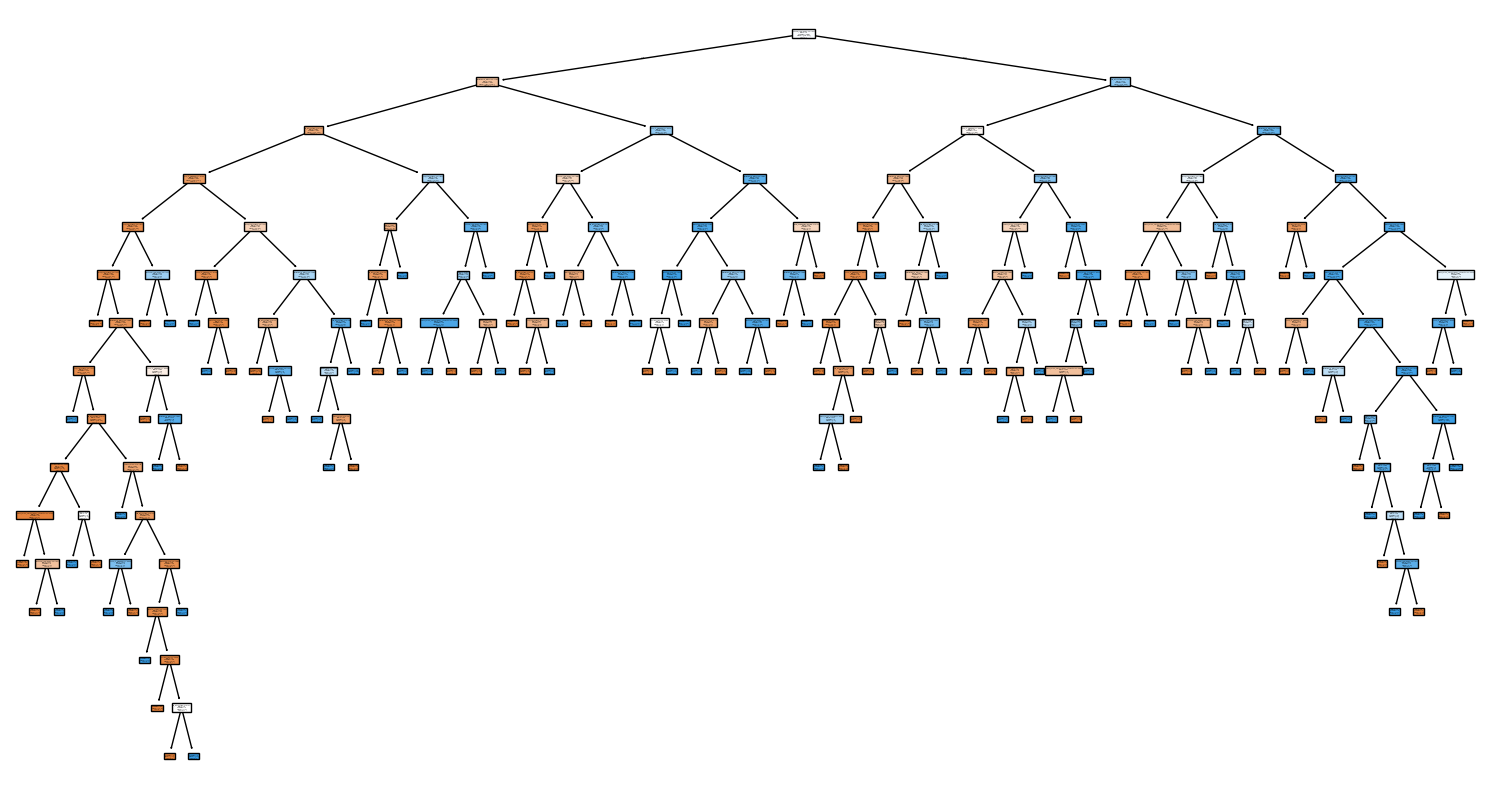

In [75]:
plt.figure(figsize=(15, 8))

plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    class_names=["1","0"],
    # max_depth=1
)
plt.tight_layout()
plt.show()

# SVR

In [78]:
from sklearn.svm import SVC

svr = SVC()
svr.fit(X_train, y_train)

SVC()

In [80]:
y_pred = svr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"the accuracy is {acc*100}%")

the accuracy is 89.25925925925927%


# Random Forest

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 201,
    oob_score = True,
    max_depth=4
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
train_pred = rf.predict(X_train)
print("oob score is : ", rf.oob_score_*100)
print(f"testing accuracy is {accuracy_score(y_test, y_pred)*100}%")
print("accuracy is ", accuracy_score(y_train, train_pred)*100)

oob score is :  84.9074074074074
testing accuracy is 84.81481481481481%
accuracy is  91.01851851851852


# XG Boost

In [84]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators =100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

In [85]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [98]:
y_pred = model.predict(X_test)
train_pred = model.predict(X_train)
print("accuracy is ", accuracy_score(y_test, y_pred)*100)
print("accuracy is ", accuracy_score(y_train, train_pred)*100)

accuracy is  90.0
accuracy is  97.5925925925926


# Gradient Boosting 

In [89]:
from sklearn.ensemble import GradientBoostingClassifier

In [91]:
gbc = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=150,
    max_depth=3,
    random_state=42
)

In [93]:
gbc.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=150, random_state=42)

In [97]:
y_pred = gbc.predict(X_test)
train_pred = gbc.predict(X_train)
print("accuracy is ", accuracy_score(y_test, y_pred)*100)
print("accuracy is ", accuracy_score(y_train, train_pred)*100)


accuracy is  92.96296296296296
accuracy is  99.9074074074074
